In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 실습 1. 문자열 날짜를 시간으로 변환
df = pd.read_csv('.venv/20_engine01_timestamp_sample.csv')

print(f'원래 timestamp 컬럼의 타입은 {df['timestamp'].dtype}입니다.')
df['timestamp'] = pd.to_datetime(df['timestamp'])
print(f'변환된 timestamp 컬럼의 타입은 {df['timestamp'].dtype}입니다.')

원래 timestamp 컬럼의 타입은 str입니다.
변환된 timestamp 컬럼의 타입은 datetime64[us]입니다.


In [3]:
# 실습 2. 시간 조작 추출과 파생 열
# timestamp 컬럼이 datetime64 타입이라서 부분을 뽑내기 가능 : year, day, hour, min
print(df['timestamp'].dt.year.head(1))
print(df['timestamp'].dt.month.head(1))
print(df['timestamp'].dt.day.head(1))

# 다른 방식으로 첫 값 확인
print(df['timestamp'].dt.year.iloc[1])
print(df['timestamp'].dt.month.iloc[1])
print(df['timestamp'].dt.day.iloc[1])
print(df['timestamp'].dt.hour.iloc[1])

# hour 시리즈를 기존 df에 새로운 컬럼으로 추가
df['hour']= df['timestamp'].dt.hour
print(df['hour'].head(3).tolist())

0    2024
Name: timestamp, dtype: int32
0    3
Name: timestamp, dtype: int32
0    1
Name: timestamp, dtype: int32
2024
3
1
1
[0, 1, 2]


In [4]:
# 실습 3. 시간 인덱스 만들고 정렬

df = df.set_index('timestamp').sort_index()
print(df.index.dtype)

print(df.index[0])
print(df.index[-1])

print(f'전체행 : {len(df)}')

datetime64[us]
2024-03-01 00:00:00
2024-03-08 23:00:00
전체행 : 182


In [5]:
# 실습 4. 시간 인덱스로 기간 잘라보기

day = df.loc['2024-03-02']
print(len(day)) # 20

range = df.loc['2024-03-05' : '2024-03-07']
print(len(range)) # 70

20
70


In [6]:
# 실습 5. 시간 단위 평균최댓값 집계
# 시계열로 timestamp를 정렬된 인덱스로 만들어서
# 다운샘플링하기
# 1. 어떤 단위로 다시 붂을 것인가? 시간단위 ->월, 6시간 등등
# 2. 새로 묶어서 통계내는 대상 컬럼은? temp_out을 써봅시다.

print(df['temp_out'].head(2)) # timestamp가 인덱스로 잡힌 것 확인
print(df['temp_out'].resample('6h').mean().head(3))
print(df['temp_out'].resample('6h').max().head(3))
print(df['temp_out'].resample('6h').min().head(3))
print(df['temp_out'].resample('6h').median().head(3))
# 6시간 단위로 다운샘플링해서 temp_out 컬럼의 평균들을 구하기

timestamp
2024-03-01 00:00:00    641.17
2024-03-01 01:00:00    640.66
Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    641.058333
2024-03-01 06:00:00    641.005000
2024-03-01 12:00:00    640.953333
Freq: 6h, Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    641.18
2024-03-01 06:00:00    641.27
2024-03-01 12:00:00    641.23
Freq: 6h, Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    640.66
2024-03-01 06:00:00    640.84
2024-03-01 12:00:00    640.71
Freq: 6h, Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    641.130
2024-03-01 06:00:00    640.955
2024-03-01 12:00:00    640.935
Freq: 6h, Name: temp_out, dtype: float64


In [7]:
# 실습 6. 리샘플링 단위와 데이터

print(len(df['temp_out'].resample('1h').mean())) # 192
print(len(df['temp_out'].resample('6h').mean())) # 32
print(len(df['temp_out'].resample('12h').mean())) # 16

for time in ['1h', '6h', '12h']:
    print(len(df['temp_out'].resample(time).mean()))
# 192 32 16

192
32
16
192
32
16


timestamp
2024-03-01    641.067273
2024-03-02    641.340000
Freq: D, Name: temp_out, dtype: float64


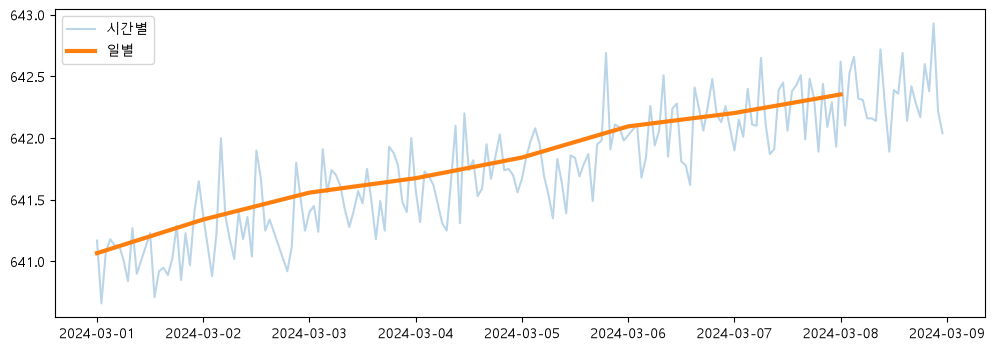

첫날 평균 641.07


In [8]:
# 실습 7. 일별 집계로 추세 확인

daily = df['temp_out'].resample('1D').mean()
print(daily.head(2))

plt.figure(figsize=(12, 4))
plt.plot(df.index, df['temp_out'], alpha=0.3, label='시간별')
plt.plot(daily.index, daily.values, linewidth=3, label='일별')
plt.legend()
plt.show()
print(f'첫날 평균 {daily.iloc[0].round(2)}') # 첫날 평균 641.07
# 2024-03-01    641.067273
# 2024-03-02    641.340000
# 2024-03-03    641.557917


In [9]:
# 실습 8. 업샘플링 결측과 보간
up = df['flow'].resample('30min').mean()
print(f'업샘플링 결측 : {up.isna().sum().sum()}') # 201
print(f'보간 후 결측 : {up.interpolate().isna().sum().sum()}') # 0
print(f'진동 원본 결측 {df['vibration'].isna().sum().sum()}, 보간 후 {df['vibration'].interpolate().isna().sum().sum()}')

# 업샘플링 결측 : 201
# 보간 후 결측 : 0
# 진동 원본 결측 3, 보간 후 0

업샘플링 결측 : 201
보간 후 결측 : 0
진동 원본 결측 3, 보간 후 0
